In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import LlamaForCausalLM, LlamaConfig, AutoTokenizer
import math
import collections
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Utility Functions
# ==========================================

def cleanup_memory():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def repeat_kv(hidden_states: torch.Tensor, n_rep: int) -> torch.Tensor:
    batch, num_key_value_heads, slen, head_dim = hidden_states.shape
    if n_rep == 1: return hidden_states
    hidden_states = hidden_states[:, :, None, :, :].expand(batch, num_key_value_heads, n_rep, slen, head_dim)
    return hidden_states.reshape(batch, num_key_value_heads * n_rep, slen, head_dim)

def apply_rotary_pos_emb(q, cos, sin, position_ids):
    def rotate_half(x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)
    q_f32 = q.float()
    cos = cos[position_ids].unsqueeze(1).float()
    sin = sin[position_ids].unsqueeze(1).float()
    q_embed = (q_f32 * cos) + (rotate_half(q_f32) * sin)
    return q_embed.to(q.dtype)

def manual_rmsnorm(hidden_states, weight, variance_epsilon):
    input_dtype = hidden_states.dtype
    hidden_states = hidden_states.to(torch.float32)
    variance = hidden_states.pow(2).mean(-1, keepdim=True)
    hidden_states = hidden_states * torch.rsqrt(variance + variance_epsilon)
    return weight * hidden_states.to(input_dtype)

def topp_temperature_decode(logits, temperature=0.6, top_p=0.9):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cumulative_probs > top_p
    mask[:, :, 1:] = mask[:, :, :-1].clone()
    mask[:, :, 0] = False
    sorted_probs.masked_fill_(mask, 0.0)
    sorted_probs /= sorted_probs.sum(dim=-1, keepdim=True)
    sampled_indices = torch.multinomial(sorted_probs.squeeze(1), num_samples=1)
    return sorted_indices.gather(dim=-1, index=sampled_indices.unsqueeze(-1)).squeeze(-1)

# ==========================================
# LSH Indexing
# ==========================================

class LSH:
    """
    Standard hash table structure.
    Functionally equivalent to a set of L independent hash functions h_l(x).
    """
    def __init__(self, K, L, num_layers, num_heads, num_kv_heads, batch_size, max_length, device='cuda:0'):
        self.tables = []
        self.num_heads = num_heads
        self.num_attention_groups = num_heads // num_kv_heads
        self.device = device
        for _ in range(num_layers):
            layer_tables = []
            for _ in range(batch_size):
                head_tables = [[collections.defaultdict(list) for _ in range(L)] for _ in range(num_kv_heads)]
                layer_tables.append(head_tables)
            self.tables.append(layer_tables)

    def clear(self):
        for layer_idx in range(len(self.tables)):
            for req_id in range(len(self.tables[0])):
                for head_idx in range(len(self.tables[0][0])):
                    for table in self.tables[layer_idx][req_id][head_idx]:
                        table.clear()

    def fill(self, layer_id, request_id, hash_codes, indices):
        hc = hash_codes.cpu()
        idx = indices.cpu().tolist()
        num_kv, L, _ = hc.shape
        for h in range(num_kv):
            for l in range(L):
                table_dict = self.tables[layer_id][request_id][h][l]
                hashes = hc[h, l].tolist()
                for i, val in enumerate(hashes):
                    table_dict[val].append(idx[i])

    def batch_retrieve(self, layer_id, query_hash_codes):
        B_H, L = query_hash_codes.shape
        query_hash_codes = query_hash_codes.cpu()
        results = []
        for i in range(B_H):
            req_id = i // self.num_heads
            kv_head_id = (i % self.num_heads) // self.num_attention_groups
            counts = collections.defaultdict(int)
            for l in range(L):
                val = query_hash_codes[i, l].item()
                bucket = self.tables[layer_id][req_id][kv_head_id][l].get(val, [])
                for idx in bucket:
                    counts[idx] += 1
            candidates = [idx for idx, count in counts.items() if count >= 1]
            results.append(torch.tensor(candidates, dtype=torch.long, device=self.device) if candidates else torch.empty(0, dtype=torch.long, device=self.device))
        return results

# ==========================================
# Sparse Attention Estimators (SNIS)
# ==========================================

def _compute_core_attention(q, k, v, k_norm, head_dim):
    """
    Computes exact dot product and angular distance theta.
    Theta is required to compute the ground-truth collision probability p(theta).
    """
    if k.shape[0] == 0:
        return torch.zeros(1, head_dim, device=q.device, dtype=q.dtype), None, None

    score_f = torch.matmul(q.float(), k.float().transpose(0, 1)).squeeze(0)
    denom = q.float().norm(p=2) * k_norm.float()
    cos_theta = torch.clamp(score_f / (denom + 1e-6), -1.0 + 1e-4, 1.0 - 1e-4)
    theta = torch.acos(cos_theta)
    return score_f, theta

def _apply_snis_and_project(score_f, log_w, v, head_dim, is_exact):
    """
    Standard SNIS projection: sum(w_i * v_i) / sum(w_i).
    Subtracting log_w in log-space is equivalent to division by importance weight w in linear space.
    """
    if is_exact is not None:
        log_w = torch.where(is_exact, torch.zeros_like(log_w), log_w)

    score_f = score_f / math.sqrt(head_dim) - log_w
    attn_probs = torch.softmax(score_f, dim=0)
    return torch.matmul(attn_probs.unsqueeze(0), v.float()).to(v.dtype)

def magicpig_transform(q, k, v, k_norm, K, L, head_dim, is_exact=None):
    """
    Baseline MagicPIG Estimator.
    Assumes a fixed retrieval depth K across all L trees.
    Sampling probability: u_i = 1 - (1 - p(theta)^K)^L
    """
    score_f, theta = _compute_core_attention(q, k, v, k_norm, head_dim)
    if theta is None: return score_f

    prob = 1.0 - theta / math.pi
    p = prob.pow(K)
    q_prob = 1.0 - p
    w = 1.0 - q_prob.pow(L)
    log_w = torch.log(w + 1e-4)

    return _apply_snis_and_project(score_f, log_w, v, head_dim, is_exact)

def jungle_snis_transform(q, k, v, k_norm, retrieval_depths, L, head_dim, is_exact=None):
    """
    Jungle Estimator with Depth-Dependent Weights.
    The importance weight is conditioned on the *actual* retrieval depth delta_i.
    u_i(delta) = 1 - (1 - p(theta)^delta)^L
    This stabilizes the variance when the algorithm backtracks to shallower depths.
    """
    score_f, theta = _compute_core_attention(q, k, v, k_norm, head_dim)
    if theta is None: return score_f

    p_base = 1.0 - theta / math.pi

    # Critical: Use the dynamic depth (K or K-1) for the proposal distribution
    p_collision = p_base.pow(retrieval_depths.float())
    w = 1.0 - (1.0 - p_collision).pow(L)
    log_w = torch.log(torch.clamp(w, min=1e-10))

    return _apply_snis_and_project(score_f, log_w, v, head_dim, is_exact)

In [11]:
# ==========================================
# Server & Logic
# ==========================================

class AttentionLogger:
    def __init__(self): self.reset()
    def reset(self): self.stats = collections.defaultdict(list)
    def log(self, key, value): self.stats[key].append(value)
    def get_aggregated_stats(self):
        if not self.stats["total_tokens"]: return {}
        total = np.mean(self.stats["total_tokens"])
        sparse = np.mean(self.stats["sparse_tokens"])
        backtrack_rate = 0.0
        if "backtracks" in self.stats:
            backtrack_rate = np.mean(self.stats["backtracks"])
        return {
            'avg_total_tokens': total,
            'avg_sparse_tokens': sparse,
            'sparsity_ratio': sparse/total if total>0 else 0,
            'backtrack_rate': backtrack_rate
        }

class LSHSparseAttnServer:
    def __init__(self, config, K=10, L=150, batch_size=1, num_sink_tokens=2, num_local_tokens=8,
                 max_length=8192, dense_layers=[0, 16, 32], device='cuda:0', dtype=torch.bfloat16,
                 verbose=False, use_jungle=False, do_naive_jungle=False):
        self.config = config
        self.K, self.L = K, L
        self.batch_size, self.max_length = batch_size, max_length
        self.num_sink_tokens, self.num_local_tokens = num_sink_tokens, num_local_tokens
        self.dense_layers = set(dense_layers)
        self.device, self.dtype = device, dtype
        self.verbose = verbose
        self.use_jungle = use_jungle
        self.do_naive_jungle = do_naive_jungle

        self.logger = AttentionLogger()
        self.step_counter = 0
        self.layer_errors = collections.defaultdict(list)
        self.jg_K_max, self.jg_L = K, L

        self.num_layers = config.num_hidden_layers
        self.num_heads = config.num_attention_heads
        self.num_kv_heads = config.num_key_value_heads
        self.head_dim = config.hidden_size // self.num_heads
        self.num_attention_groups = self.num_heads // self.num_kv_heads

        self.k_cache = [torch.zeros(batch_size, self.num_kv_heads, max_length, self.head_dim, device=device, dtype=dtype) for _ in range(self.num_layers)]
        self.v_cache = [torch.zeros(batch_size, self.num_kv_heads, max_length, self.head_dim, device=device, dtype=dtype) for _ in range(self.num_layers)]
        self.avg_k_cache = [torch.zeros(batch_size, self.num_kv_heads, 1, self.head_dim, device=device, dtype=dtype) for _ in range(self.num_layers)]
        self.current_len = [0] * batch_size
        self.sparse_boundaries = {}

        self.lsh = LSH(K, L, self.num_layers, self.num_heads, self.num_kv_heads, batch_size, max_length, device)

        #
        self.hash_func = torch.randn((self.head_dim, K * L), device=device, dtype=dtype)
        self.binary_pack = 2 ** torch.arange(K, device=device, dtype=torch.float32)

        if self.use_jungle:
            self.jg_projs = torch.randn(self.head_dim, self.jg_L * self.jg_K_max, device=device, dtype=dtype)
            self.jg_hash_cache = collections.defaultdict(dict)

    def clear(self):
        self.lsh.clear()
        self.logger.reset()
        self.layer_errors = collections.defaultdict(list)
        self.step_counter = 0
        self.current_len = [0] * self.batch_size
        self.sparse_boundaries = {}
        if self.use_jungle: self.jg_hash_cache.clear()
        for l in range(self.num_layers):
            self.k_cache[l].zero_()
            self.v_cache[l].zero_()
            self.avg_k_cache[l].zero_()

    def step(self):
        self.step_counter += 1
        for i in range(self.batch_size): self.current_len[i] += 1

    def fill(self, layer_idx, request_id, key_states, value_states, start_pos):
        seq_len = key_states.shape[0]
        end_pos = start_pos + seq_len
        self.k_cache[layer_idx][request_id, :, start_pos:end_pos, :] = key_states.transpose(0, 1)
        self.v_cache[layer_idx][request_id, :, start_pos:end_pos, :] = value_states.transpose(0, 1)
        if end_pos > self.current_len[request_id]: self.current_len[request_id] = end_pos

        if layer_idx not in self.dense_layers:
            # Only hash non-local, non-sink tokens
            idx_start, idx_end = max(start_pos, self.num_sink_tokens), end_pos - self.num_local_tokens
            self.sparse_boundaries[request_id] = max(self.num_sink_tokens, idx_end)

            if idx_end > idx_start:
                keys = self.k_cache[layer_idx][request_id, :, idx_start:idx_end, :]
                avg_k = keys.float().mean(dim=1, keepdim=True).to(self.dtype)
                self.avg_k_cache[layer_idx][request_id] = avg_k
                centered = keys - avg_k

                if self.use_jungle:
                    bits = (torch.matmul(centered, self.jg_projs) > 0).float()
                    bits = bits.view(self.num_kv_heads, bits.shape[1], self.jg_L, self.jg_K_max)
                    if layer_idx not in self.jg_hash_cache: self.jg_hash_cache[layer_idx] = {}
                    self.jg_hash_cache[layer_idx][request_id] = bits
                else:
                    bits = (torch.matmul(centered, self.hash_func) > 0).float().view(self.num_kv_heads, -1, self.L, self.K)
                    buckets = torch.matmul(bits, self.binary_pack).long().permute(0, 2, 1)
                    self.lsh.fill(layer_idx, request_id, buckets, torch.arange(idx_start, idx_end, device=self.device))

    def decode(self, query_states, key_states, value_states, layer_idx):
        bsz, n_heads, _, dim = query_states.shape

        for req_id in range(bsz):
            curr = self.current_len[req_id]
            self.k_cache[layer_idx][req_id, :, curr:curr+1, :] = key_states[req_id]
            self.v_cache[layer_idx][req_id, :, curr:curr+1, :] = value_states[req_id]

        hidden_states_list = []
        layer_errors = []

        for req_id in range(bsz):
            q_heads = query_states[req_id, :, 0, :]
            curr_len = self.current_len[req_id]
            idx_to_hash = curr_len - self.num_local_tokens

            # Incremental hashing of new token entering sparse region
            if layer_idx not in self.dense_layers and idx_to_hash >= self.num_sink_tokens:
                key_to_hash = self.k_cache[layer_idx][req_id, :, idx_to_hash:idx_to_hash+1, :]
                avg_k = self.avg_k_cache[layer_idx][req_id]
                centered = key_to_hash - avg_k

                if self.use_jungle:
                    bits = (torch.matmul(centered, self.jg_projs) > 0).float()
                    bits = bits.view(self.num_kv_heads, 1, self.jg_L, self.jg_K_max)
                    prev_bits = self.jg_hash_cache[layer_idx][req_id]
                    self.jg_hash_cache[layer_idx][req_id] = torch.cat([prev_bits, bits], dim=1)
                else:
                    bits = (torch.matmul(centered, self.hash_func) > 0).float().view(self.num_kv_heads, 1, self.L, self.K)
                    buckets = torch.matmul(bits, self.binary_pack).long().permute(0, 2, 1)
                    idx_tensor = torch.tensor([idx_to_hash], device=self.device)
                    self.lsh.fill(layer_idx, req_id, buckets, idx_tensor)
                self.sparse_boundaries[req_id] = max(self.num_sink_tokens, idx_to_hash + 1)

            # Exact Attention for Dense Layers (0, 1, etc)
            if layer_idx in self.dense_layers:
                k = repeat_kv(self.k_cache[layer_idx][req_id, :, :curr_len, :].unsqueeze(0), self.num_attention_groups).squeeze(0)
                v = repeat_kv(self.v_cache[layer_idx][req_id, :, :curr_len, :].unsqueeze(0), self.num_attention_groups).squeeze(0)
                scores = torch.matmul(q_heads.float().unsqueeze(1), k.float().transpose(1, 2)) / math.sqrt(dim)
                hidden_states_list.append(torch.matmul(torch.softmax(scores, dim=-1), v.float()).squeeze(1).to(self.dtype))
                if req_id == 0: self.layer_errors[layer_idx].append(0.0)
                continue

            # Sparse Retrieval Logic
            head_outputs = []
            norm_q = q_heads / (q_heads.norm(p=2, dim=-1, keepdim=True) + 1e-6)

            if self.use_jungle:
                jg_q_bits = (torch.matmul(norm_q, self.jg_projs) > 0).float().view(self.num_heads, self.jg_L, self.jg_K_max)
            else:
                bits = (torch.matmul(norm_q, self.hash_func) > 0).float().view(self.num_heads, self.L, self.K)
                idx_list = self.lsh.batch_retrieve(layer_idx, torch.matmul(bits, self.binary_pack).long().unsqueeze(0).view(-1, self.L))

            backtrack_count = 0
            total_trees = 0
            backtracked_trees = 0

            for h in range(self.num_heads):
                kv_head = h // self.num_attention_groups
                sparse_boundary = self.sparse_boundaries.get(req_id, 0)

                # Always include Sink and Local tokens (MagicPIG requirement)
                sink_indices = torch.arange(0, min(curr_len, self.num_sink_tokens), device=self.device)
                local_indices = torch.arange(max(sparse_boundary, 0), curr_len, device=self.device) if curr_len > sparse_boundary else torch.empty(0, dtype=torch.long, device=self.device)

                sparse_indices = torch.empty(0, dtype=torch.long, device=self.device)
                retrieved_depths = torch.empty(0, dtype=torch.float32, device=self.device)

                if self.use_jungle and layer_idx in self.jg_hash_cache and req_id in self.jg_hash_cache[layer_idx]:
                    k_bits = self.jg_hash_cache[layer_idx][req_id][kv_head]
                    q_bits = jg_q_bits[h]

                    # Compute longest common prefix depth for all trees
                    match_matrix = (k_bits == q_bits.unsqueeze(0)).int()
                    depths = match_matrix.cumprod(dim=-1).sum(dim=-1) # [N_sparse, Trees]

                    # -----------------------------------------------------------
                    # NAIVE JUNGLE (Static Tree)
                    # -----------------------------------------------------------
                    if self.do_naive_jungle:
                        min_depth = self.jg_K_max
                        valid_mask = (depths >= min_depth)
                        is_selected = valid_mask.any(dim=1)
                        selected_indices = torch.nonzero(is_selected).squeeze(-1)
                        if selected_indices.numel() > 0:
                            sparse_indices = selected_indices + self.num_sink_tokens
                            token_depths_all_trees = depths[selected_indices]
                            max_depths, _ = token_depths_all_trees.max(dim=1)
                            retrieved_depths = torch.clamp(max_depths.float(), max=float(self.jg_K_max))

                    # -----------------------------------------------------------
                    # JUNGLE BACKTRACKING
                    # -----------------------------------------------------------
                    else:
                        #

                        # Check for signal at full depth K
                        full_match_mask = (depths == self.jg_K_max)
                        has_full_match = full_match_mask.any(dim=0) # [Trees]

                        # Policy: If signal absent at K, backtrack to K-1 (Scheme S_low)
                        needs_backtrack = ~has_full_match
                        total_trees += self.jg_L
                        backtracked_trees += needs_backtrack.sum().item()

                        backtrack_match_mask = (depths >= (self.jg_K_max - 1))
                        if needs_backtrack.any(): backtrack_count += 1

                        # Select indices based on dynamic depth per tree
                        final_mask = torch.where(has_full_match.unsqueeze(0), full_match_mask, backtrack_match_mask)
                        is_selected = final_mask.any(dim=1)
                        selected_indices = torch.nonzero(is_selected).squeeze(-1)

                        if selected_indices.numel() > 0:
                            sparse_indices = selected_indices + self.num_sink_tokens
                            # Assign importance weight depth (K vs K-1)
                            token_full_matches = full_match_mask[selected_indices].any(dim=1)
                            retrieved_depths = torch.where(token_full_matches,
                                                     torch.tensor(self.jg_K_max, device=self.device, dtype=torch.float32),
                                                     torch.tensor(self.jg_K_max - 1, device=self.device, dtype=torch.float32))

                elif not self.use_jungle:
                    # Standard Flat LSH Retrieval
                    raw_indices = idx_list[h]
                    if raw_indices.numel() > 0:
                        sparse_indices = raw_indices[(raw_indices >= self.num_sink_tokens) & (raw_indices < sparse_boundary)]

                if h == 0 and req_id == 0:
                    self.logger.log("total_tokens", self.current_len[0])
                    self.logger.log("sparse_tokens", sparse_indices.numel())
                    if self.use_jungle and not self.do_naive_jungle:
                        rate = backtracked_trees / total_trees if total_trees > 0 else 0.0
                        self.logger.log("backtracks", rate)

                full_indices = torch.cat([sink_indices, sparse_indices, local_indices]).unique()

                # Gather KV stats and Norms
                k_sel = self.k_cache[layer_idx][req_id, kv_head, full_indices, :]
                v_sel = self.v_cache[layer_idx][req_id, kv_head, full_indices, :]
                k_sel_centered = k_sel - self.avg_k_cache[layer_idx][req_id, kv_head, 0, :]
                k_norm_sel = k_sel_centered.float().norm(p=2, dim=-1)

                # Mask exact tokens (Sink/Local) so SNIS weights = 1.0 (log_w = 0)
                is_exact = (full_indices < self.num_sink_tokens) | (full_indices >= sparse_boundary)

                # Compute Estimator
                if self.use_jungle:
                    depth_map = torch.zeros(full_indices.shape[0], device=self.device)
                    if sparse_indices.numel() > 0:
                        sparse_map = {idx.item(): d.item() for idx, d in zip(sparse_indices, retrieved_depths)}
                        depth_list = [sparse_map.get(idx.item(), 0.0) for idx in full_indices]
                        depth_map = torch.tensor(depth_list, device=self.device)
                    out_h = jungle_snis_transform(q_heads[h].unsqueeze(0), k_sel_centered, v_sel, k_norm_sel, depth_map, self.jg_L, self.head_dim, is_exact)
                else:
                    out_h = magicpig_transform(q_heads[h].unsqueeze(0), k_sel_centered, v_sel, k_norm_sel, self.K, self.L, self.head_dim, is_exact)

                # Compute Ground Truth for Error Logging
                gt_k = self.k_cache[layer_idx][req_id, kv_head, :curr_len, :]
                gt_v = self.v_cache[layer_idx][req_id, kv_head, :curr_len, :]
                gt_out = torch.matmul(torch.softmax(torch.matmul(q_heads[h].unsqueeze(0), gt_k.transpose(0, 1)) / math.sqrt(dim), dim=-1), gt_v).to(self.dtype)

                diff = gt_out - out_h
                error = diff.norm() / (gt_out.norm() + 1e-6)
                layer_errors.append(error.item())
                head_outputs.append(out_h)

            if req_id == 0:
                self.layer_errors[layer_idx].append(np.mean(layer_errors))
            hidden_states_list.append(torch.cat(head_outputs, dim=0))

        return torch.stack(hidden_states_list, dim=0).view(bsz, 1, n_heads * dim)

# ==========================================
# Model Wrappers (Boilerplate)
# ==========================================

class LLMLayer:
    def __init__(self, layer_idx, hf_layer, device):
        self.layer_idx, self.device = layer_idx, device
        self.wq = hf_layer.self_attn.q_proj.weight.detach().to(device)
        self.wk = hf_layer.self_attn.k_proj.weight.detach().to(device)
        self.wv = hf_layer.self_attn.v_proj.weight.detach().to(device)
        self.wo = hf_layer.self_attn.o_proj.weight.detach().to(device)
        self.gate_proj = hf_layer.mlp.gate_proj.weight.detach().to(device)
        self.up_proj = hf_layer.mlp.up_proj.weight.detach().to(device)
        self.down_proj = hf_layer.mlp.down_proj.weight.detach().to(device)
        self.input_ln_w = hf_layer.input_layernorm.weight.detach().to(device)
        self.input_ln_eps = hf_layer.input_layernorm.variance_epsilon
        self.post_ln_w = hf_layer.post_attention_layernorm.weight.detach().to(device)
        self.post_ln_eps = hf_layer.post_attention_layernorm.variance_epsilon

    def forward(self, hidden_states, position_ids, attn_server, cos, sin, is_prefill=False):
        residual = hidden_states
        hidden_states = manual_rmsnorm(hidden_states, self.input_ln_w, self.input_ln_eps)
        bsz, q_len, _ = hidden_states.shape
        q = F.linear(hidden_states, self.wq).view(bsz, q_len, attn_server.num_heads, -1).transpose(1, 2)
        k = F.linear(hidden_states, self.wk).view(bsz, q_len, attn_server.num_kv_heads, -1).transpose(1, 2)
        v = F.linear(hidden_states, self.wv).view(bsz, q_len, attn_server.num_kv_heads, -1).transpose(1, 2)
        q, k = apply_rotary_pos_emb(q, cos, sin, position_ids), apply_rotary_pos_emb(k, cos, sin, position_ids)
        if is_prefill:
            for i in range(bsz):
                attn_server.fill(self.layer_idx, i, k[i].permute(1, 0, 2), v[i].permute(1, 0, 2), position_ids[i, 0].item())
            n_rep = attn_server.num_heads // attn_server.num_kv_heads
            attn_out = F.scaled_dot_product_attention(q, repeat_kv(k, n_rep), repeat_kv(v, n_rep), is_causal=True)
            attn_out = attn_out.transpose(1, 2).reshape(bsz, q_len, -1)
        else:
            attn_out = attn_server.decode(q, k, v, self.layer_idx)
        hidden_states = residual + F.linear(attn_out, self.wo)
        residual = hidden_states
        hidden_states = manual_rmsnorm(hidden_states, self.post_ln_w, self.post_ln_eps)
        up, gate = F.linear(hidden_states, self.up_proj), F.linear(hidden_states, self.gate_proj)
        return residual + F.linear(F.silu(gate) * up, self.down_proj)

class LLM:
    def __init__(self, model_name, K=10, L=150, max_length=2048, device='cuda:0', use_jungle=False, do_naive_jungle=False):
        self.device, self.max_length = device, max_length
        self.config = LlamaConfig.from_pretrained(model_name)
        print(f"Loading Model: {model_name}...")
        hf_model = LlamaForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
        self.embed_tokens = hf_model.model.embed_tokens.weight.detach().to(device)
        self.lm_head = hf_model.lm_head.weight.detach().to(device)
        self.norm_w = hf_model.model.norm.weight.detach().to(device)
        self.norm_eps = hf_model.model.norm.variance_epsilon
        inv_freq = hf_model.model.rotary_emb.inv_freq.detach().to(device)
        t = torch.arange(max_length, device=device, dtype=inv_freq.dtype)
        freqs = torch.outer(t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.cos, self.sin = emb.cos().to(torch.bfloat16), emb.sin().to(torch.bfloat16)
        self.layers = []
        for idx, layer in enumerate(hf_model.model.layers):
            self.layers.append(LLMLayer(idx, layer, device))
            hf_model.model.layers[idx] = None
            gc.collect()
        self.attn_server = LSHSparseAttnServer(self.config, K=K, L=L, max_length=max_length, device=device,
                                               use_jungle=use_jungle, do_naive_jungle=do_naive_jungle,
                                               dense_layers=[0, 10, 21])
        del hf_model
        cleanup_memory()

    def generate(self, input_ids, max_tokens=100, temperature=0.6, verbose=False):
        self.attn_server.clear()
        self.attn_server.verbose = verbose
        bsz, seq_len = input_ids.shape
        pos_ids = torch.arange(seq_len, device=self.device).unsqueeze(0)
        hidden = F.embedding(input_ids, self.embed_tokens)
        for layer in self.layers:
            hidden = layer.forward(hidden, pos_ids, self.attn_server, self.cos, self.sin, is_prefill=True)
        generated = []
        curr_pos = seq_len
        logits = F.linear(manual_rmsnorm(hidden[:,-1:], self.norm_w, self.norm_eps), self.lm_head)
        next_token = topp_temperature_decode(logits, temperature)
        generated.append(next_token.item())
        start_time = time.time()
        for _ in range(max_tokens):
            hidden = F.embedding(next_token, self.embed_tokens)
            pos_ids = torch.tensor([[curr_pos]], device=self.device)
            for layer in self.layers:
                hidden = layer.forward(hidden, pos_ids, self.attn_server, self.cos, self.sin, is_prefill=False)
            self.attn_server.step()
            logits = F.linear(manual_rmsnorm(hidden, self.norm_w, self.norm_eps), self.lm_head)
            next_token = topp_temperature_decode(logits, temperature)
            generated.append(next_token.item())
            curr_pos += 1
            if next_token.item() in [128001, 128009]: break
        duration = time.time() - start_time
        stats = self.attn_server.logger.get_aggregated_stats()
        stats.update({'tps': len(generated)/duration if duration>0 else 0, 'layer_errors': self.attn_server.layer_errors})
        return generated, stats


🔎 NIAH Test (Jungle (Backtrack)) | Len: 1995
Loading Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
   Result: ❌ MISSED
   Output: ''BROWN_PINEAPPLE_32'.</s> 
<|user|>'
   Sparsity: 18.4%

🔎 NIAH Test (Jungle (Naive)) | Len: 1995
Loading Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
   Result: ✅ FOUND
   Output: ''BLUE_PINEAPPLE_42'.</s> 
<|user|>'
   Sparsity: 16.5%

🔎 NIAH Test (Standard LSH) | Len: 1995
Loading Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
   Result: ✅ FOUND
   Output: ''BLUE_PINEAPPLE_42'.</s> 
<|user|>'
   Sparsity: 16.4%


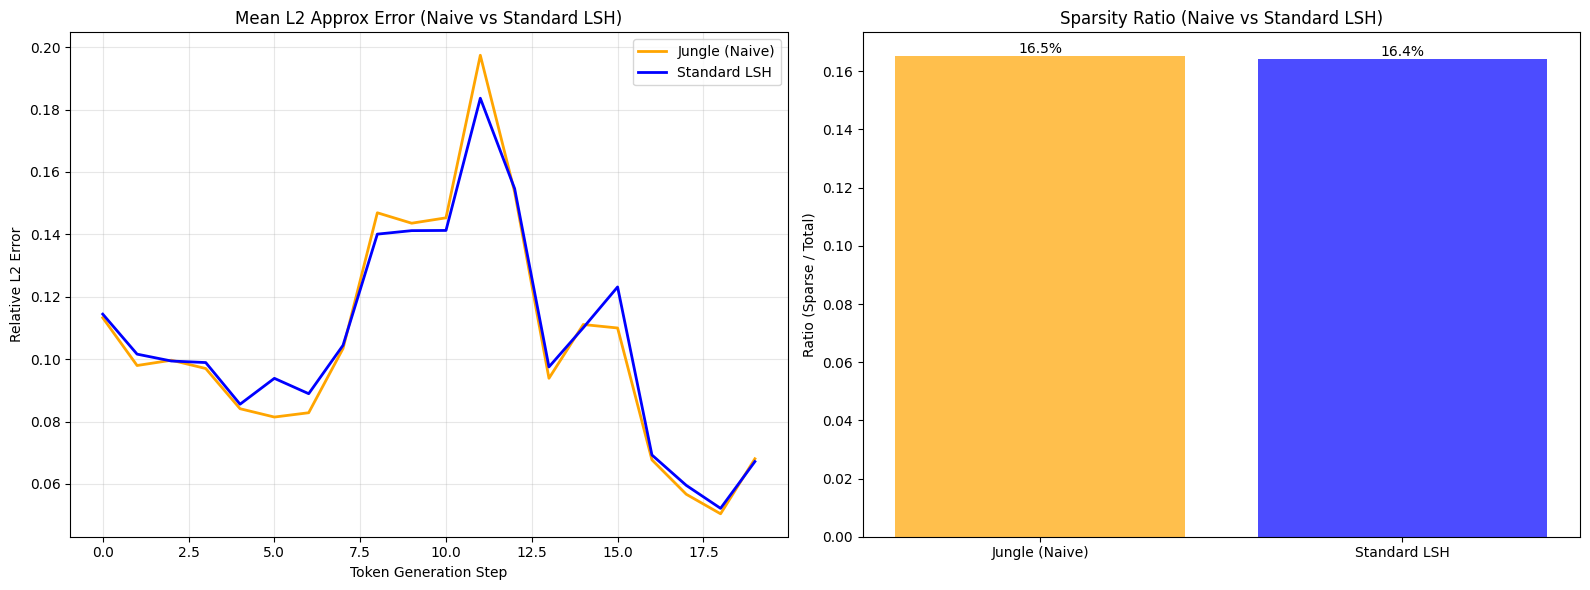

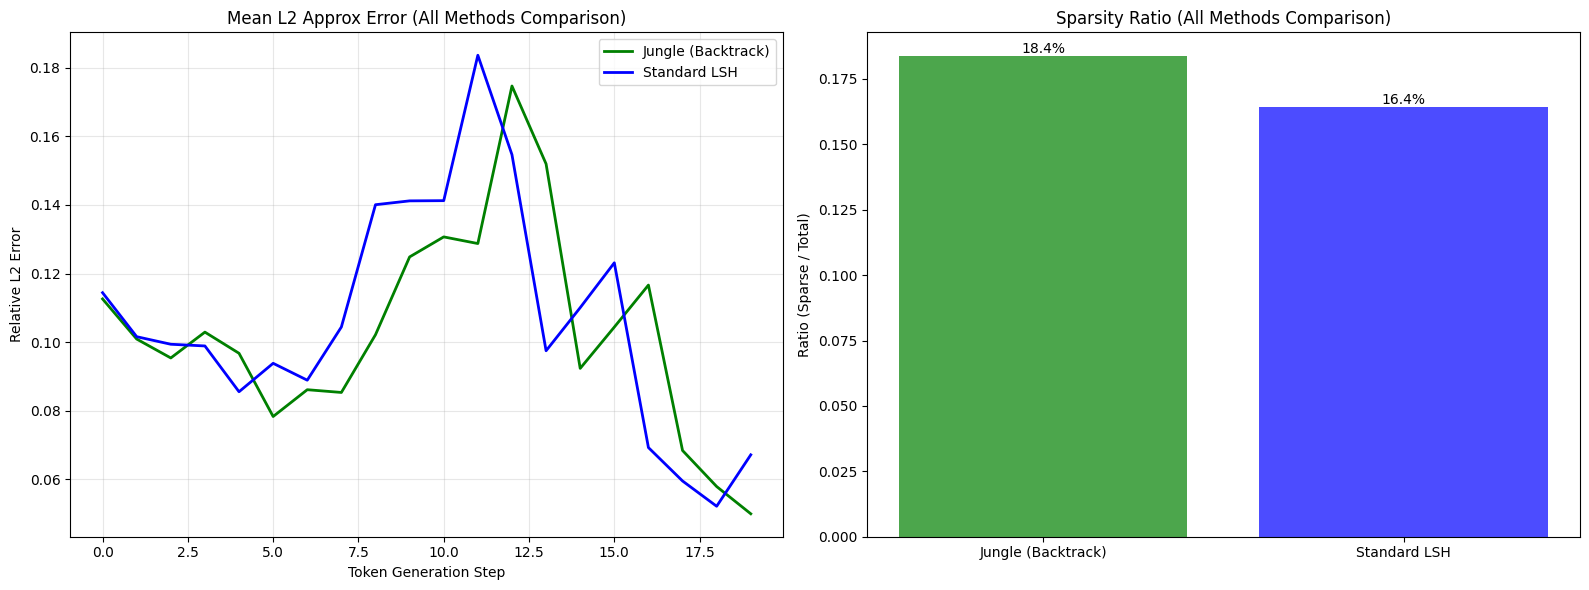

In [12]:
# ==========================================
# Experiment Harness & Evaluation
# ==========================================

def run_niah_test(tokenizer, model_name, device, method_config, context_length=4096, depth_pct=0.5):
    use_jungle = method_config.get('use_jungle', False)
    do_naive = method_config.get('do_naive', False)
    label = method_config.get('label', 'Unknown')
    needle = " The password is 'BLUE_PINEAPPLE_42'. "
    filler = " This is the noise term for the haystack."
    query = " What is the password? The password is"
    n_ids = tokenizer.encode(needle, add_special_tokens=False)
    f_ids = tokenizer.encode(filler, add_special_tokens=False)
    q_ids = tokenizer.encode(query, add_special_tokens=False)
    remaining = context_length - len(n_ids) - len(q_ids)
    full_context = f_ids * (remaining // len(f_ids))
    insert_idx = int(len(full_context) * depth_pct)
    final_ids = full_context[:insert_idx] + n_ids + full_context[insert_idx:] + q_ids
    input_tensor = torch.tensor([final_ids], device=device)
    print(f"\n🔎 NIAH Test ({label}) | Len: {len(final_ids)}")
    try:
        llm = LLM(model_name, K=10, L=150, max_length=context_length+200, device=device,
                  use_jungle=use_jungle, do_naive_jungle=do_naive)
        start_t = time.time()
        out_ids, stats = llm.generate(input_tensor, max_tokens=20, verbose=False)
        end_t = time.time()
        output_text = tokenizer.decode(out_ids)
        success = "BLUE_PINEAPPLE_42" in output_text
        status = "✅ FOUND" if success else "❌ MISSED"
        print(f"   Result: {status}")
        print(f"   Output: '{output_text.strip()}'")
        print(f"   Sparsity: {stats.get('sparsity_ratio', 0)*100:.1f}%")
        del llm
        cleanup_memory()
        return stats, stats.get('layer_errors', {})
    except Exception as e:
        print(f"   [CRASH]: {e}")
        import traceback; traceback.print_exc()
        return {}, {}


if __name__ == "__main__":
    MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL)

    print("="*80)

    # Define all experiments
    configs = [
        {'label': 'Jungle (Backtrack)', 'use_jungle': True, 'do_naive': False, 'color': 'green'},
        {'label': 'Jungle (Naive)', 'use_jungle': True, 'do_naive': True, 'color': 'orange'},
        {'label': 'Standard LSH', 'use_jungle': False, 'do_naive': False, 'color': 'blue'}
    ]

    results = {}

    for cfg in configs:
        stats, errors = run_niah_test(tokenizer, MODEL, DEVICE, cfg, context_length=2000, depth_pct=0.5)
        results[cfg['label']] = {'stats': stats, 'errors': errors, 'color': cfg['color']}

    plot_scenarios = [
        ("Naive vs Standard LSH", ['Jungle (Naive)', 'Standard LSH']),
        ("All Methods Comparison", ['Jungle (Backtrack)', 'Standard LSH'])
    ]

    for title_suffix, labels_to_include in plot_scenarios:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        current_results = {k: v for k, v in results.items() if k in labels_to_include}

        # 1. Error Plot
        for label, data in current_results.items():
            approx_layers = [errs for l_idx, errs in data['errors'].items() if np.sum(errs) > 0]
            if approx_layers:
                mean_errs = np.mean(approx_layers, axis=0)
                ax1.plot(range(len(mean_errs)), mean_errs, label=label, color=data['color'], linewidth=2)

        ax1.set_title(f'Mean L2 Approx Error ({title_suffix})')
        ax1.set_xlabel('Token Generation Step')
        ax1.set_ylabel('Relative L2 Error')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Sparsity Bar Chart
        plot_labels = list(current_results.keys())
        sparsity_vals = [d['stats'].get('sparsity_ratio', 0) for d in current_results.values()]
        plot_colors = [d['color'] for d in current_results.values()]

        ax2.bar(plot_labels, sparsity_vals, color=plot_colors, alpha=0.7)
        ax2.set_title(f'Sparsity Ratio ({title_suffix})')
        ax2.set_ylabel('Ratio (Sparse / Total)')
        for i, v in enumerate(sparsity_vals):
            ax2.text(i, v, f"{v*100:.1f}%", ha='center', va='bottom')

        plt.tight_layout()
        plt.show()